# Préliminaires

In [20]:
# Import des paquets

import pandas as pd
import os
import load_data.donnees_chargement
from great_tables import GT
import statsmodels.api as sm

# Fonctions annexes
from utilities.utilities import *

# Statistique exploratoire

## Audience de la télévision

## Sujets des journaux TV

## Répartition du temps de parole femme / homme à la télévision

In [2]:
# Import des donnees

parite = load_data.donnees_chargement.load_parite()
parite.head()

,media_type,channel_code,channel_name,is_public_channel,date,week_day,school_holiday_zones,civil_holyday,hour,male_duration,female_duration,music_duration
636822,tv,ART,ARTE,True,2010-01-01,Friday,ABC,True,12,829.06,371.28,2056.80
636823,tv,ART,ARTE,True,2010-01-01,Friday,ABC,True,14,148.42,68.56,2993.40
636824,tv,ART,ARTE,True,2010-01-01,Friday,ABC,True,18,1722.84,307.90,1238.96
636825,tv,ART,ARTE,True,2010-01-01,Friday,ABC,True,21,2714.88,329.62,286.16
636826,tv,ART,ARTE,True,2010-01-02,Saturday,ABC,False,11,1254.78,1243.14,1070.86


On commence par renommer les jours de la semaine avec leurs numéros, afin que l'ordre soit le bon.

In [3]:
# Formatage des jours

parite['week_day_number'] = parite['week_day'].replace({
        'Monday': 1,
        'Tuesday': 2,
        'Wednesday': 3,
        'Thursday': 4,
        'Friday': 5,
        'Saturday': 6,
        'Sunday': 7
})
    

/tmp/ipykernel_72244/1942983103.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  parite['week_day_number'] = parite['week_day'].replace({


### Proportion du temps de parole féminin par chaîne

La première exploration effectuée consiste à calculer, pour chacune des chaînes observées et sur toute la période, de janvier 2010 à février 2019, présente dans les données, la proportion du temps de parole féminin.

Notons que nous n'avons chargé que les données des cinq chaînes dont nous connaissons par ailleurs les thématiques abordées au JT, à savoir Arte, France 2, France 3, M6 et TF1.

In [4]:
# Calcul du temps de parole féminin et masculin par chaine

# Sommes des temps de parole masculin et féminin sur la période
parite_chaine = parite.groupby('channel_code').agg(
    channel_name = ('channel_name', 'first'),
    female_duration = ('female_duration', 'sum'),
    male_duration = ('male_duration', 'sum')
).reset_index()

# Proportion du temps de parole féminin
parite_chaine['proportion_female'] = parite_chaine['female_duration'] / (parite_chaine['female_duration'] + parite_chaine['male_duration'])

# Tri des chaînes de la plus féminisée à la moins féminisée
parite_chaine = parite_chaine.sort_values(by='proportion_female', ascending=False).reset_index()

In [5]:
# Affichage de la part de parole féminine par chaîne

(
    GT(parite_chaine[['channel_name', 'proportion_female']])
    .tab_header(
        title="Part du temps de parole féminin par chaîne",
        subtitle="De janvier 2010 à février 2019"
    )
    .fmt_percent(columns="proportion_female", decimals=0)
    .cols_label(
        channel_name = "Chaîne",
        proportion_female = "Part du temps de parole féminin"
    )
    .cols_width(cases={
        'channel_name': '70px',
        'proportion_female': '150px'
    })
    .tab_source_note("Source : INA")
)

GT(_tbl_data=  channel_name  proportion_female
0           M6           0.411471
1          TF1           0.364962
2     France 2           0.343634
3     France 3           0.318630
4         ARTE           0.291878, _body=<great_tables._gt_data.Body object at 0x7f1bfabcf0e0>, _boxhead=Boxhead([ColInfo(var='channel_name', type=<ColInfoTypeEnum.default: 1>, column_label='Chaîne', column_align='left', column_width='70px'), ColInfo(var='proportion_female', type=<ColInfoTypeEnum.default: 1>, column_label='Part du temps de parole féminin', column_align='right', column_width='150px')]), _stub=<great_tables._gt_data.Stub object at 0x7f1bfabcef90>, _spanners=Spanners([]), _heading=Heading(title='Part du temps de parole féminin par chaîne', subtitle='De janvier 2010 à février 2019', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7f1bfabce7b0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7f1bfa9ec190>, _source_notes=['Source : INA'], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x7f1bfabce660>, _formats=[<great_tables._gt_data.FormatInfo object at 0x7f1bfabce900>], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_bottom_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_bottom_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_bottom_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_left_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_left_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_left_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), heading_background_color=OptionsInfo(scss=True, category='heading', type='va

On remarque tout d'abord que la parité n'est atteinte par aucune chaîne : M6, la chaîne la plus féminisée, n'a que 41% de son temps de parole occupé par des femmes.
Par ailleurs, les chaînes privées M6 et TF1 sont plus féminisées que les chaînes publique. ARTE arrive dernière avec seulement 29% de temps de parole occupé par des femmes.

### Proportion du temps de parole féminin par jour de la semaine

Nous regardons ensuite si le jour de la semaine a un impact sur la proportion du temps de parole féminin. Nous présentons nos résultats sous forme de diagrammes en barres.
Nous ne présentons les résultats que pour ARTE et France 2, qui ont des comportements très différents.

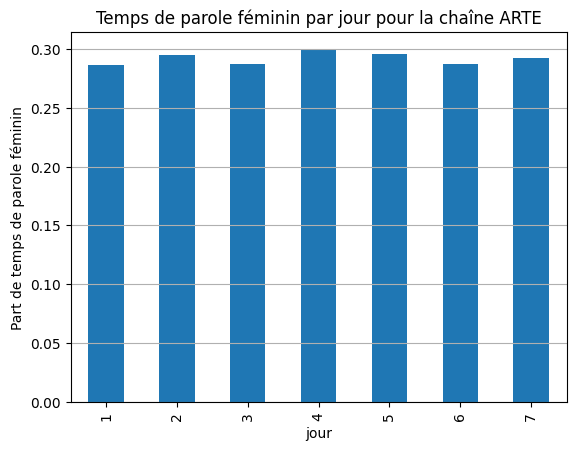

In [6]:
# Arte

diagramme_temps_parole_var(df=parite, variable='week_day_number', code_chaine='ART', label='jour')

Pour la chaîne ARTE, on ne remarque pas une grande différence entre les jours.
La piste du jour de la semaine pour expliquer la répartition du temps de parole ne semble pas être à privilégier pour cette chaîne.

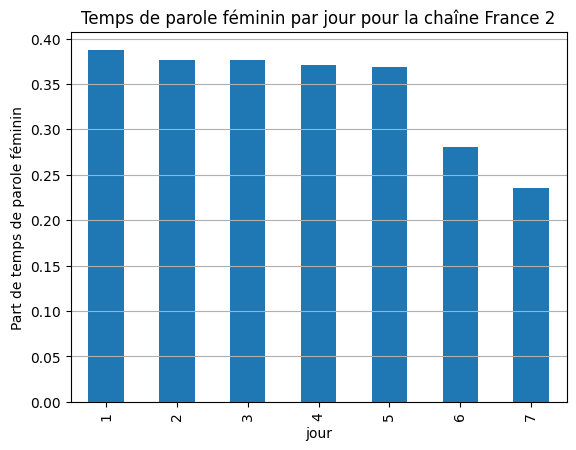

In [7]:
# France 2

diagramme_temps_parole_var(df=parite, variable='week_day_number', code_chaine='FR2', label='jour')

Pour France 2 en revanche, on consate un net décrochage du temps de parole féminin le week-end, et notamment le dimanche.

### Proportion du temps de parole féminin par mois de l'année

À présent, nous nous intéressons au temps de parole féminin par mois de l'année pour les différentes chaînes.
Nous ne présentons les résultats que pour TF1, France 2 et ARTE.

In [8]:
# Création de la variable "mois de l'année"

parite['year_month_number'] = parite['date'].dt.month

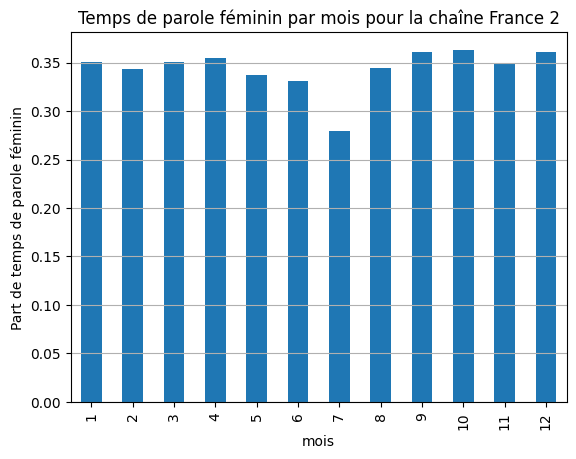

In [9]:
# France 2
diagramme_temps_parole_var(df=parite, variable='year_month_number', code_chaine='FR2', label='mois')

Sur France 2, on remarque un décrochage en juillet.
Hypothèse : ce décrochage est dû à la diffusion du Tour de France

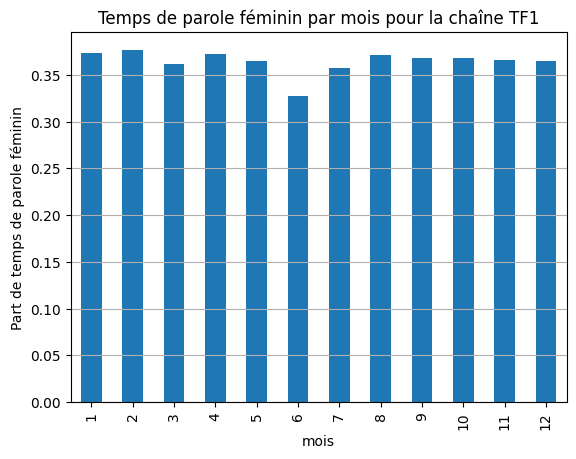

In [10]:
# TF1
diagramme_temps_parole_var(df=parite, variable='year_month_number', code_chaine='TF1', label='mois')

Sur TF1, on remarque un décrochage en juin
Hypothèse : ce décrochage est dû aux mondiaux et euros de football

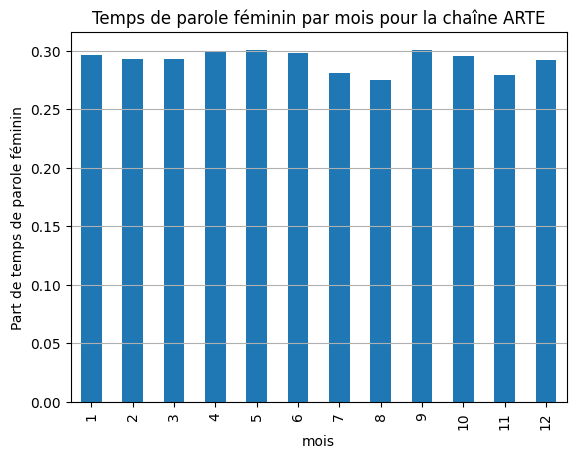

In [11]:
# ARTE
diagramme_temps_parole_var(df=parite, variable='year_month_number', code_chaine='ART', label='mois')

Sur ARTE en revanche, les différences entre les mois de l'année sont peu notables.

### Évolution du temps de parole féminin

Enfin, nous regardons, pour les différentes chaînes, l'évolution du temps de parole féminin au cours de la période considérée.

Nous prenons le mois comme unité temporelle.

Nous ne présentons les résultats que pour France 2 et TF1, pour lesquelles cette évolution nous a interpellés.

In [12]:
# Evolution du temps de parole féminin

# Date au mois près 
parite['monthly_date'] = parite['date'].dt.to_period('M')

# Aggrégation des données par mois et chaîne
parite_evolution_chaine = parite.groupby(['monthly_date', 'channel_code']).agg(
    male_duration = ('male_duration', 'sum'),
    female_duration = ('female_duration', 'sum'),
    channel_name = ('channel_name', 'first')
).reset_index()

# Proportion de temps de parole féminin
parite_evolution_chaine['proportion_female'] = (
    parite_evolution_chaine['female_duration'] / (parite_evolution_chaine['female_duration'] + parite_evolution_chaine['male_duration'])
)

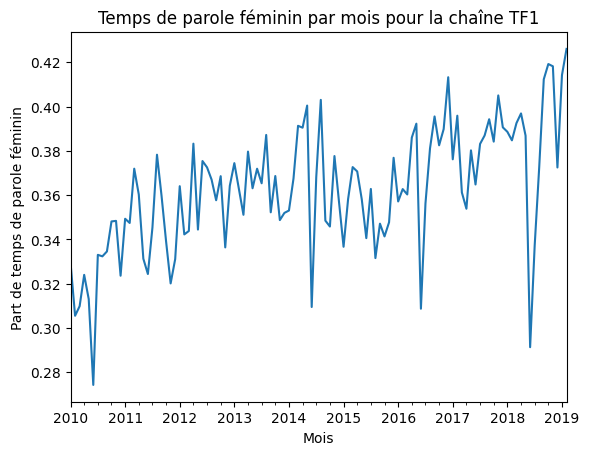

In [15]:
# TF1

diagramme_temps_parole_evolution(df=parite_evolution_chaine, code_chaine='TF1')

On remarque pour TF1 une tendance à la hausse du temps de parole féminin, ainsi que d'importants reculs aux étés 2010, 2014, 2016 et 2018.
Hypothèse : ces reculs sont dûs aux euros et mondiaux de football.

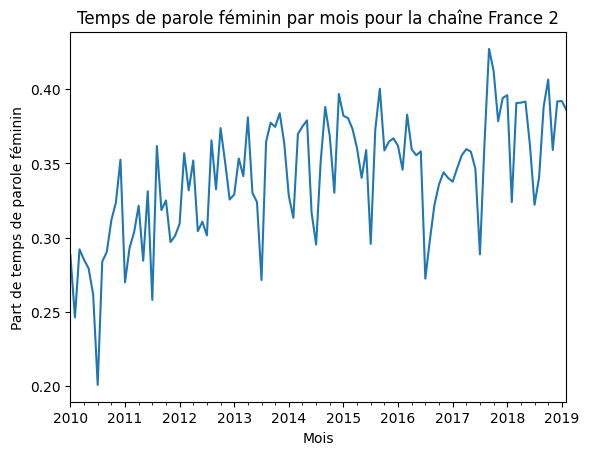

In [16]:
# France 2

diagramme_temps_parole_evolution(df=parite_evolution_chaine, code_chaine='FR2')

À nouveau, on remarque une tendance à la hausse du temps de parole féminin, et des reculs récurrents en été.
Hypothèse : ces reculs estivaux sont liés aux compétitions sportives estivales (Roland-Garrs, Tour de France, Mondiaux de football.)

### Conclusion

Les compétitions sportives semblent jouer un grand rôle (négatif). dans le temps de parole des femmes à la télévision.
Pour confirmaer cela, il nous semble pertinent de régresser la proportion de temps de parole des femmes sur la présence des différents thèmes aux actualités.

# Modélisation

## Répartition du temps de parole femme / homme et sujets d'actualité

Comme annoncé en conclusion des statistiques exploratoires sur la périté à la télévision, nous allons régresser la proportion du temps de parole féminin cumulé pour l'ensemble des chaînes ARTE, France 2, France 3, TF1 et M6 sur les sujets d'actualités présentés aux journaux télévisés de ces mêmes chaînes.

Notre unité de temps est le mois.

### Constitution d'un DataFrame pour la régression

In [17]:
## Dataframe des temps relatifs de chaque sujets, indexés par mois

# import de sujets_jt
sujets_jt = load_data.donnees_chargement.load_sujet_tele()

# Date en mois
sujets_jt['date_mois'] = sujets_jt['Date'].dt.to_period('M')

# Regroupement des temps pour chaque sujets selon les mois
sujets_jt_mois = sujets_jt.groupby(['date_mois', 'Thématique']).agg(
    Duree_sec = ('Duree_sec', 'sum'),
    Nb_sujets = ('Nb_sujets', 'sum'),
).reset_index()

# Temps total de JT pour chaque mois
temps_jt_mois = sujets_jt_mois.groupby(['date_mois']).agg(
    Duree_totale_jt = ('Duree_sec', 'sum')
).reset_index()

# Regroupement des deux informations dans un DataFrame
sujets_jt_mois = pd.merge(sujets_jt_mois, temps_jt_mois, on = 'date_mois')

# Proportion de chaque sujet par rapport au temps total de JT
sujets_jt_mois['prop'] = sujets_jt_mois['Duree_sec'] / (sujets_jt_mois['Duree_totale_jt'])

# Une ligne par mois
sujets_jt_mois_wide = pd.pivot(sujets_jt_mois, index='date_mois', columns='Thématique', values='prop')

/home/onyxia/work/Projet_python_2A/load_data/donnees_chargement.py:18: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  sujet_tele['Temps_total_JT'] = sujet_tele.groupby(['Date','Chaîne'])['Duree_sec'].transform(sum)


In [18]:
## Mise en relation avec l'évolution du temps de parole féminin

# Évolution du temps de parole félinin cumulé sur les cinq chaînes
parite_evolution = parite_evolution_chaine.groupby('monthly_date').agg(
    male_duration = ('male_duration', 'sum'),
    female_duration = ('female_duration', 'sum')
).reset_index()

parite_evolution['proportion_female'] = parite_evolution['female_duration'] / (parite_evolution['female_duration'] + parite_evolution['male_duration'])

# Fusion avec les temps des sujets du JT
parite_sujets_jt_mois = pd.merge(parite_evolution, sujets_jt_mois_wide, left_on = 'monthly_date', right_on='date_mois')

In [19]:
# Définition des variables

X = parite_sujets_jt_mois[[
    'Catastrophes', 
    'Economie', 
    'Faits divers', 
    'International', 
    'Sport', 
    'Culture-loisirs', 
    'Education', 
    'Environnement', 
    'Politique France', 
    'Histoire-hommages', 
    'Justice',
    'Santé',
    'Sciences et techniques',
    'Société']]
    
y = parite_sujets_jt_mois['proportion_female']

### Un premier modèle

Nous commençons par régresser le temps de parole féminin avec l'ensemble des thématiques du journal télévisé comme variables explicativesS.

In [21]:
# Ajout de la constante dans les variables explicatives
Xc = sm.add_constant(X)

# Calcul des paramètres du modème
mod = sm.OLS(y, Xc)
modfit = mod.fit()

# Affichage du modèle
print(modfit.summary())

                            OLS Regression Results                            
Dep. Variable:      proportion_female   R-squared:                       0.617
Model:                            OLS   Adj. R-squared:                  0.564
Method:                 Least Squares   F-statistic:                     11.77
Date:                Sun, 19 Apr 2026   Prob (F-statistic):           1.01e-14
Time:                        22:13:47   Log-Likelihood:                 322.78
No. Observations:                 109   AIC:                            -617.6
Df Residuals:                      95   BIC:                            -579.9
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      0

La thématique "Sport" est significative pour expliquer le temps de parole féminin, mais moins que d'autres.
Les thématiques "Économie", "Culture-loisirs", "Histoires-hommages" et "Sciences et techniques" sont également significatives.
La thématique "Culture-Loisir", en particulier, semble être corrélée très négativement au temps de parole féminin.
Cela nous étonne. Nous mettons donc en regard l'évolution de la part de la thématique "Culture-loisir" au JT avec l'évolution du temps de parole féminin.

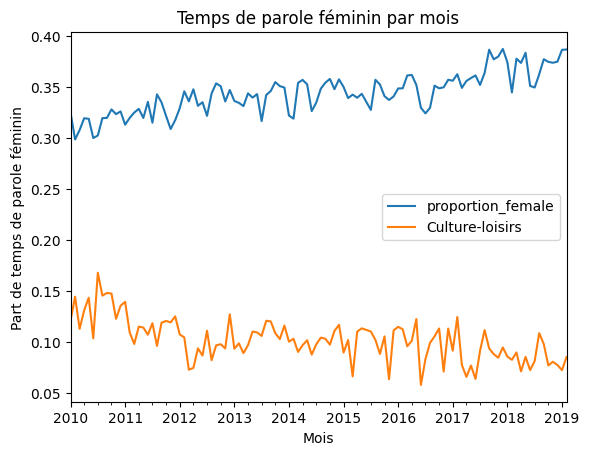

In [ ]:
diag = parite_sujets_jt_mois.set_index('monthly_date')[['proportion_female', 'Culture-loisirs']].plot(
    title = "Temps de parole féminin par mois",
    legend=True,
    xlabel="Mois",
    ylabel="Part de temps de parole féminin",
)

On voit que c'est la tendance sur 10 ans qui explique cette corrélation négative : tendance à la hausse pour la proportion de parole féminine, et à la baisse pour la thématique "Culture-loisirs au journal.

Nous ne souhaitons pas considérer la tendance pour faire un lien entre part de parole féminine et thématique du JT.
Nous réalisons donc une nouvelle régression en enlevant une tendance linéaire pour l'évolution de la parole féminine.

### Modèle sans tendance

À présent, nous régressons le temps de parole féminin, en ôtant sa tendance, toujours sur l'ensemble des thématiques du JT.

In [23]:
## Calcul de la tendance de la part de parole féminine

# Colonne 'index' avec un nombre pour chaque mois
parite_sujets_jt_mois = parite_sujets_jt_mois.reset_index()

# Définition de la variable temporelle
T = parite_sujets_jt_mois['index']

# Ajout de la constante
Tc = sm.add_constant(T)

# Calcul des paramètres de la tendance linéaire
modT = sm.OLS(y, Tc)
modTfit = modT.fit()

# Extraction des paramètres de la tendance linéaire
coeffs = modTfit.params
cons = coeffs[0] # Ordonnée à l'origine
trend = coeffs[1] # Pente

/tmp/ipykernel_72244/1528524421.py:18: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  cons = coeffs[0] # Ordonnée à l'origine
/tmp/ipykernel_72244/1528524421.py:19: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  trend = coeffs[1] # Pente


In [25]:
## Définition du temps de parole féminin sans la tendance

parite_sujets_jt_mois['proportion_female_detrend'] = (
    parite_sujets_jt_mois['proportion_female'] - cons - trend * parite_sujets_jt_mois['index']
)

# Variable à expliquer pour la régression
y_detrend = parite_sujets_jt_mois['proportion_female_detrend']

In [26]:
## Régression du temps de parole sans tendance sur les thématiques du JT

mod_detrend = sm.OLS(y_detrend, Xc)
mod_detrendfit = mod_detrend.fit()

print(mod_detrendfit.summary())

                                OLS Regression Results                               
Dep. Variable:     proportion_female_detrend   R-squared:                       0.410
Model:                                   OLS   Adj. R-squared:                  0.329
Method:                        Least Squares   F-statistic:                     5.080
Date:                       Sun, 19 Apr 2026   Prob (F-statistic):           9.49e-07
Time:                               22:29:03   Log-Likelihood:                 357.64
No. Observations:                        109   AIC:                            -687.3
Df Residuals:                             95   BIC:                            -649.6
Df Model:                                 13                                         
Covariance Type:                   nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------

On voit que seule la thématique "Sport" est significative à 1%. Cependant, la thématique Culture-Loisirs est toujours significative à 5%. Aucune autre thématiques n'est significative à 5%.

Afin de confirmer la significativité de ces deux thématiques, nous régressons le temps de parole féminin sur les thématiques "Sport" et "Culture-loisirs" uniquement.

### Régression uniquement sur les thématiques "Sport" et "Culture-loisirs"

In [27]:
## Définition des variables

Xsign = parite_sujets_jt_mois[[
    'Sport', 
    'Culture-loisirs']]

# Ajout de la constante
Xsignc = sm.add_constant(Xsign)

In [29]:
## Ajustement du modèle

mod = sm.OLS(y_detrend, Xsignc)
modfit = mod.fit()

print(modfit.summary())

                                OLS Regression Results                               
Dep. Variable:     proportion_female_detrend   R-squared:                       0.244
Model:                                   OLS   Adj. R-squared:                  0.230
Method:                        Least Squares   F-statistic:                     17.09
Date:                       Sun, 19 Apr 2026   Prob (F-statistic):           3.69e-07
Time:                               22:38:46   Log-Likelihood:                 344.11
No. Observations:                        109   AIC:                            -682.2
Df Residuals:                            106   BIC:                            -674.1
Df Model:                                  2                                         
Covariance Type:                   nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------

La thématique "Culture-loisirs" n'est plus du tout significative, tandis que la thématqiue "Sport" reste significative à 1%.
Afin de confirmer le résultat, on régresse le temps de parole féminin sur le sport uniquement.

### Régression uniquement sur la thématique "Sport"

In [30]:
sportc = sm.add_constant(parite_sujets_jt_mois['Sport'])

mod_sport = sm.OLS(y_detrend, sportc)
mod_sportfit = mod_sport.fit()

print(mod_sportfit.summary())


                                OLS Regression Results                               
Dep. Variable:     proportion_female_detrend   R-squared:                       0.242
Model:                                   OLS   Adj. R-squared:                  0.235
Method:                        Least Squares   F-statistic:                     34.20
Date:                       Sun, 19 Apr 2026   Prob (F-statistic):           5.47e-08
Time:                               22:40:42   Log-Likelihood:                 343.99
No. Observations:                        109   AIC:                            -684.0
Df Residuals:                            107   BIC:                            -678.6
Df Model:                                  1                                         
Covariance Type:                   nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------

La thématique "Sport" reste significative à 1% pour expliquer le temps de parole féminin.

### Conclusion

Les régressions linéaires effectuées confirment notre hypothèse selon laquelle la présence de sport à l'actualité a une influence notable sur la proportion de la parole féminine à la télévision.